In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)
* Making encoded patch d > 2, we do not loose any information and perplexity does not collapse. When latent vector is flat, codebook usage is lower but not harms reconstruction

Utility function import and prepearation

In [3]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [4]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [6]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 241.75it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [7]:
batch_size = 64
beta = 0.3
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)

num_epochs = 200
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2

# Latent dimension size
d = 2 # adjustable encoder width for extra compression


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
mse = MeanSquaredError()
mse = mse.to(device)

In [10]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [11]:
event_train = events_train[:SELECTED_EVENTS][0]

In [12]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [13]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [14]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [15]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z, indexes: int):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        # z = z.permute(0, 2, 3, 1).contiguous()
        # z_flattened = z.view(-1, self.e_dim).contiguous()
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))
        
        z_q = z_q.reshape(-1, indexes, self.e_dim)

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [16]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [17]:
# TODO: think about it later
class AbstractModule(nn.Module):
    
    def __init__(self) -> None:
        super().__init__()
    
    def forward(self, x: torch.tensor) -> None:
        raise NotImplemented

In [18]:
# TODO: test with 2 x 2 encoded patch

class EncoderInput(AbstractModule):
    
    # NOTE: encoder_features - from convolution network
    """
    indexes: int - how many codebook indexes could an encoded patch have    
    encoder_features: int - how many features are in encoder convolution output 
    
    """
    def __init__(self, indexes: int, slope: np.float64, latent_dim: int, encoder_features: int = 4) -> None:
        super().__init__()
        
        # TODO: in_features need to come from encoder conv network
        self.encoder_features = encoder_features
        self.layers = nn.Sequential(
            nn.Linear(in_features=encoder_features, out_features=indexes),
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(slope)
        )
        
    def forward(self, x: torch.tensor) -> None:
        b, c, w, h = x.shape
        x_flattened = x.reshape(b, c, w * h)
        x_output = self.layers(x_flattened)
        (b, c, w) = x_output.shape
        x_output_flattened = x_output.reshape(b * w, c)
        return x_output_flattened.contiguous()
    

class DecoderInput(AbstractModule):
    
    # NOTE: decoder_features - dinamically add required feature count for decoder
    
    """
    d: int - how many indexes could an encoded patch have
    decoder_features: int - how many features could a decoder convolution network have
    """
    
    def __init__(
        self, 
        indexes: int, 
        slope: np.float64, 
        decoder_features: int = 4,
    ) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=indexes, out_features=decoder_features),
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(slope)
        )
        
    def forward(self, x: torch.tensor) -> None:
        (b, w, c) = x.shape
        x = x.reshape(b, c, w)
        dec_out = self.layers(x)
        
        dec_out = dec_out.reshape(
            b,
            c,
            w,
            w
        )
        return dec_out
    

In [19]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        d: int,
        residual_slope: float = 0.08,
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        # fully connected layer for encoder input
        self.fc_encoder_input = EncoderInput(indexes=d, slope=slope, latent_dim=latent_dim)     
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        # fully connected layer for vq input
        self.fc_decoder_input = DecoderInput(indexes=d, slope=slope)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x, indexes):
        encoder_output = self.encoder(x)
        
        z = self.fc_encoder_input(encoder_output)
        # (b, c, d) -> (b * d, c)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z, indexes)
        
        output_decoder_input = self.fc_decoder_input(z_q)
        
        output = self.decoder(output_decoder_input)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [20]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    d=d, # encoded patch indexes
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels # residual hidden channels
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

Epoch 1/200: 100%|██████████| 199/199 [00:00<00:00, 274.66it/s, Loss (BCE + VQ)=0.104] 


Epoch [1/200] summary:Average Loss: VQ + BCE = 0.1722,  Average loss: BCE = 0.0945 MSE = 0.010754700087890702 avg_perplexity = 4.02545456850349
Average validation set BCE loss: 0.08851034343242645
Before compression (Training)
Shape: (13, 8, 8)


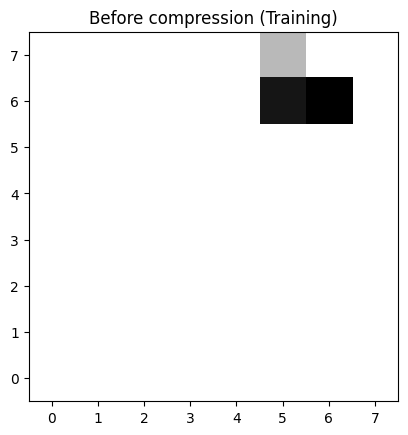

After compression (Training)
Shape: (1, 8, 8)


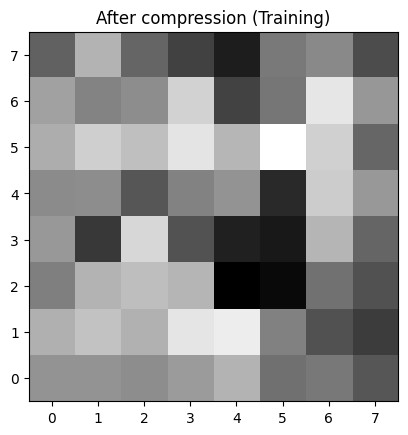

Epoch 2/200: 100%|██████████| 199/199 [00:00<00:00, 358.67it/s, Loss (BCE + VQ)=0.0649]


Epoch [2/200] summary:Average Loss: VQ + BCE = 0.0817,  Average loss: BCE = 0.0749 MSE = 0.007944857877159688 avg_perplexity = 11.1938551298937
Average validation set BCE loss: 0.06665212213993073


Epoch 3/200: 100%|██████████| 199/199 [00:00<00:00, 366.62it/s, Loss (BCE + VQ)=0.0977]


Epoch [3/200] summary:Average Loss: VQ + BCE = 0.0685,  Average loss: BCE = 0.0626 MSE = 0.00706834526002482 avg_perplexity = 18.055947423580303
Average validation set BCE loss: 0.06233365833759308


Epoch 4/200: 100%|██████████| 199/199 [00:00<00:00, 367.10it/s, Loss (BCE + VQ)=0.0528]


...

Epoch [14/200] summary:Average Loss: VQ + BCE = 0.0500,  Average loss: BCE = 0.0451 MSE = 0.004454782305182374 avg_perplexity = 42.45889310980562
Average validation set BCE loss: 0.046395710110664366


Epoch 15/200: 100%|██████████| 199/199 [00:00<00:00, 355.54it/s, Loss (BCE + VQ)=0.0566]


Epoch [15/200] summary:Average Loss: VQ + BCE = 0.0495,  Average loss: BCE = 0.0447 MSE = 0.004397986160741005 avg_perplexity = 42.99406507865867
Average validation set BCE loss: 0.046172923594713214


Epoch 16/200: 100%|██████████| 199/199 [00:00<00:00, 368.47it/s, Loss (BCE + VQ)=0.0681]


Epoch [16/200] summary:Average Loss: VQ + BCE = 0.0493,  Average loss: BCE = 0.0444 MSE = 0.004351314280097883 avg_perplexity = 43.67990838822408
Average validation set BCE loss: 0.04632349759340286
Before compression (Training)
Shape: (13, 8, 8)


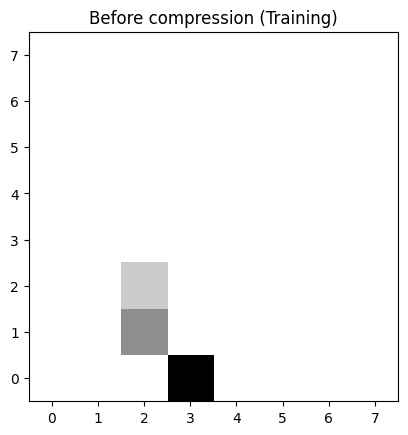

After compression (Training)
Shape: (1, 8, 8)


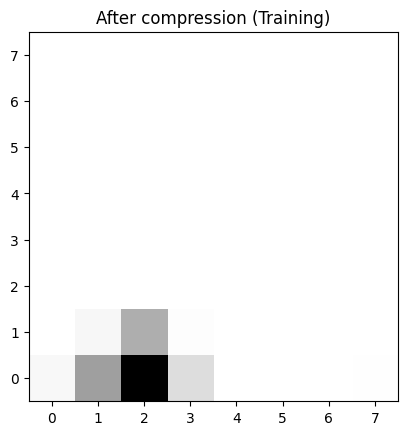

Epoch 17/200: 100%|██████████| 199/199 [00:00<00:00, 374.16it/s, Loss (BCE + VQ)=0.0548]


Epoch [17/200] summary:Average Loss: VQ + BCE = 0.0490,  Average loss: BCE = 0.0441 MSE = 0.004305647495413321 avg_perplexity = 44.2399563621636
Average validation set BCE loss: 0.04554513245820999


Epoch 18/200: 100%|██████████| 199/199 [00:00<00:00, 374.92it/s, Loss (BCE + VQ)=0.0511]


Epoch [18/200] summary:Average Loss: VQ + BCE = 0.0487,  Average loss: BCE = 0.0438 MSE = 0.00425028518642575 avg_perplexity = 44.98734372584664
Average validation set BCE loss: 0.04601137638092041


Epoch 19/200: 100%|██████████| 199/199 [00:00<00:00, 372.17it/s, Loss (BCE + VQ)=0.037] 


...

Epoch [29/200] summary:Average Loss: VQ + BCE = 0.0471,  Average loss: BCE = 0.0421 MSE = 0.003957413258639413 avg_perplexity = 48.136560411309475
Average validation set BCE loss: 0.04600830748677254


Epoch 30/200: 100%|██████████| 199/199 [00:00<00:00, 362.35it/s, Loss (BCE + VQ)=0.0458]


Epoch [30/200] summary:Average Loss: VQ + BCE = 0.0468,  Average loss: BCE = 0.0421 MSE = 0.003944244190123887 avg_perplexity = 48.23577082456656
Average validation set BCE loss: 0.044307310879230496


Epoch 31/200: 100%|██████████| 199/199 [00:00<00:00, 373.42it/s, Loss (BCE + VQ)=0.049] 


Epoch [31/200] summary:Average Loss: VQ + BCE = 0.0464,  Average loss: BCE = 0.0417 MSE = 0.00387946266713716 avg_perplexity = 48.3759466391712
Average validation set BCE loss: 0.043426088988780975
Before compression (Training)
Shape: (13, 8, 8)


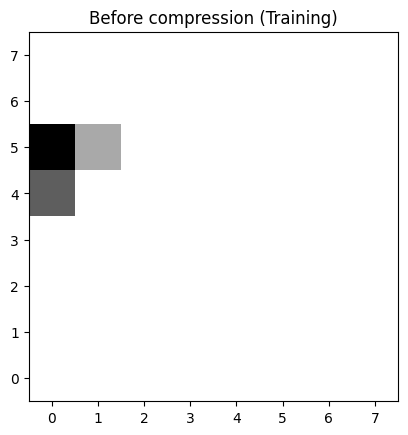

After compression (Training)
Shape: (1, 8, 8)


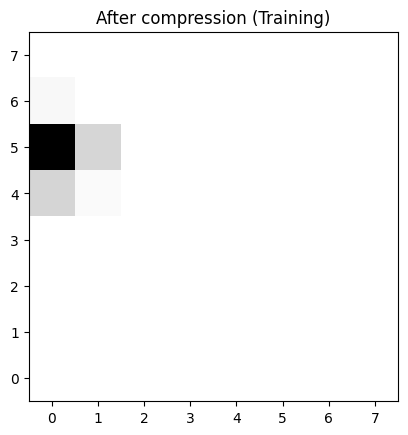

Epoch 32/200: 100%|██████████| 199/199 [00:00<00:00, 374.70it/s, Loss (BCE + VQ)=0.0625]


Epoch [32/200] summary:Average Loss: VQ + BCE = 0.0463,  Average loss: BCE = 0.0415 MSE = 0.003870606896275626 avg_perplexity = 48.83602357030514
Average validation set BCE loss: 0.04373561963438988


Epoch 33/200: 100%|██████████| 199/199 [00:00<00:00, 366.54it/s, Loss (BCE + VQ)=0.0605]


Epoch [33/200] summary:Average Loss: VQ + BCE = 0.0461,  Average loss: BCE = 0.0414 MSE = 0.0038348122075172 avg_perplexity = 49.38317628601688
Average validation set BCE loss: 0.04270853027701378


Epoch 34/200: 100%|██████████| 199/199 [00:00<00:00, 369.49it/s, Loss (BCE + VQ)=0.0768]


...

Epoch [44/200] summary:Average Loss: VQ + BCE = 0.0447,  Average loss: BCE = 0.0400 MSE = 0.0036003441308816923 avg_perplexity = 52.5478685273597
Average validation set BCE loss: 0.04280121624469757


Epoch 45/200: 100%|██████████| 199/199 [00:00<00:00, 363.44it/s, Loss (BCE + VQ)=0.0525]


Epoch [45/200] summary:Average Loss: VQ + BCE = 0.0445,  Average loss: BCE = 0.0399 MSE = 0.0036027138273526525 avg_perplexity = 52.83184351513733
Average validation set BCE loss: 0.042491594702005385


Epoch 46/200: 100%|██████████| 199/199 [00:00<00:00, 363.58it/s, Loss (BCE + VQ)=0.0583]


Epoch [46/200] summary:Average Loss: VQ + BCE = 0.0445,  Average loss: BCE = 0.0399 MSE = 0.0036006589085518866 avg_perplexity = 53.0060583430918
Average validation set BCE loss: 0.04286459013819695
Before compression (Training)
Shape: (13, 8, 8)


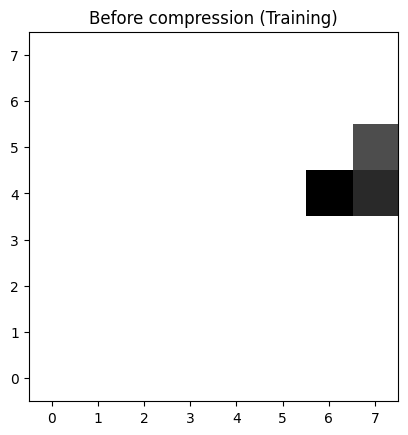

After compression (Training)
Shape: (1, 8, 8)


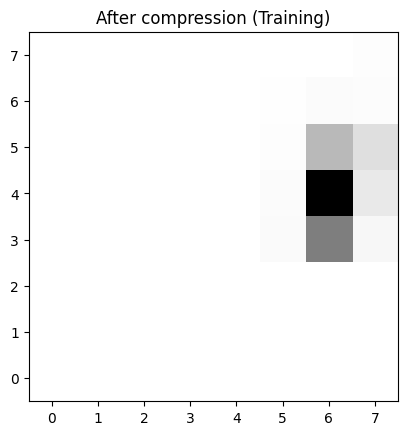

Epoch 47/200: 100%|██████████| 199/199 [00:00<00:00, 366.73it/s, Loss (BCE + VQ)=0.0414]


Epoch [47/200] summary:Average Loss: VQ + BCE = 0.0442,  Average loss: BCE = 0.0396 MSE = 0.0035380699745515107 avg_perplexity = 52.855274440056114
Average validation set BCE loss: 0.04266243055462837


Epoch 48/200: 100%|██████████| 199/199 [00:00<00:00, 364.96it/s, Loss (BCE + VQ)=0.0467]


Epoch [48/200] summary:Average Loss: VQ + BCE = 0.0442,  Average loss: BCE = 0.0397 MSE = 0.0035492094840863767 avg_perplexity = 53.01620080842444
Average validation set BCE loss: 0.042553572356700896


Epoch 49/200: 100%|██████████| 199/199 [00:00<00:00, 362.03it/s, Loss (BCE + VQ)=0.0432]


...

Epoch [59/200] summary:Average Loss: VQ + BCE = 0.0432,  Average loss: BCE = 0.0388 MSE = 0.0033896697869983 avg_perplexity = 54.48088085232069
Average validation set BCE loss: 0.041306405514478686


Epoch 60/200: 100%|██████████| 199/199 [00:00<00:00, 359.77it/s, Loss (BCE + VQ)=0.0419]


Epoch [60/200] summary:Average Loss: VQ + BCE = 0.0433,  Average loss: BCE = 0.0387 MSE = 0.0033873769357547763 avg_perplexity = 54.85755634787095
Average validation set BCE loss: 0.04179440960288048


Epoch 61/200: 100%|██████████| 199/199 [00:00<00:00, 365.96it/s, Loss (BCE + VQ)=0.0503]


Epoch [61/200] summary:Average Loss: VQ + BCE = 0.0432,  Average loss: BCE = 0.0388 MSE = 0.0034076689418414655 avg_perplexity = 54.52610421300533
Average validation set BCE loss: 0.04164161384105682
Before compression (Training)
Shape: (13, 8, 8)


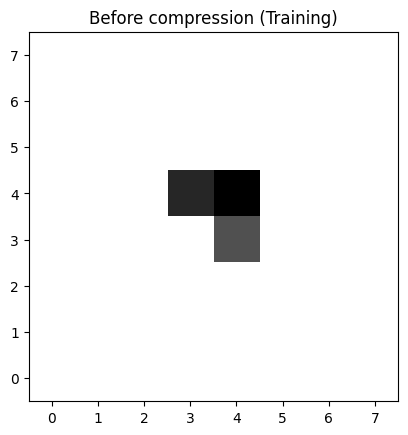

After compression (Training)
Shape: (1, 8, 8)


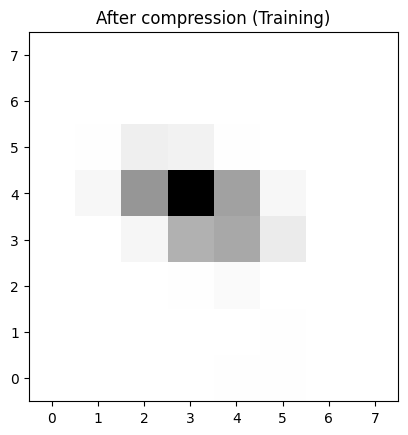

Epoch 62/200: 100%|██████████| 199/199 [00:00<00:00, 357.64it/s, Loss (BCE + VQ)=0.0382]


Epoch [62/200] summary:Average Loss: VQ + BCE = 0.0428,  Average loss: BCE = 0.0385 MSE = 0.0033600069442061924 avg_perplexity = 55.44043627216588
Average validation set BCE loss: 0.0414092130959034


Epoch 63/200: 100%|██████████| 199/199 [00:00<00:00, 367.45it/s, Loss (BCE + VQ)=0.0399]


Epoch [63/200] summary:Average Loss: VQ + BCE = 0.0428,  Average loss: BCE = 0.0385 MSE = 0.0033395004893966656 avg_perplexity = 55.42725504582851
Average validation set BCE loss: 0.04160065799951553


Epoch 64/200: 100%|██████████| 199/199 [00:00<00:00, 364.30it/s, Loss (BCE + VQ)=0.0531]


...

Epoch [74/200] summary:Average Loss: VQ + BCE = 0.0424,  Average loss: BCE = 0.0381 MSE = 0.003255418180043449 avg_perplexity = 56.684400462625014
Average validation set BCE loss: 0.041276045888662335


Epoch 75/200: 100%|██████████| 199/199 [00:00<00:00, 367.23it/s, Loss (BCE + VQ)=0.042] 


Epoch [75/200] summary:Average Loss: VQ + BCE = 0.0420,  Average loss: BCE = 0.0379 MSE = 0.0032152304865756824 avg_perplexity = 57.10302599231203
Average validation set BCE loss: 0.04092109501361847


Epoch 76/200: 100%|██████████| 199/199 [00:00<00:00, 370.38it/s, Loss (BCE + VQ)=0.0398]


Epoch [76/200] summary:Average Loss: VQ + BCE = 0.0419,  Average loss: BCE = 0.0378 MSE = 0.003215806042756792 avg_perplexity = 57.13816615924164
Average validation set BCE loss: 0.04157484471797943
Before compression (Training)
Shape: (13, 8, 8)


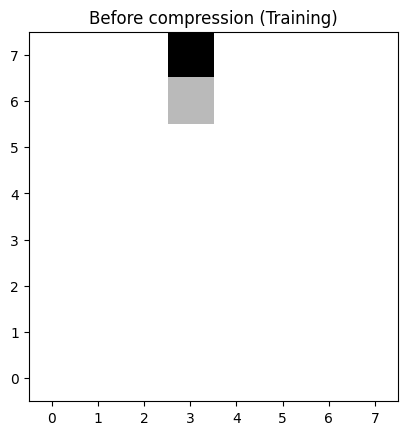

After compression (Training)
Shape: (1, 8, 8)


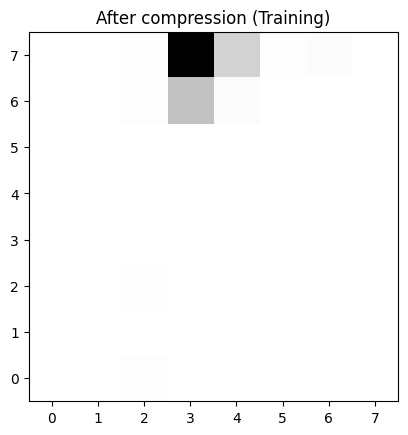

Epoch 77/200: 100%|██████████| 199/199 [00:00<00:00, 362.33it/s, Loss (BCE + VQ)=0.0536]


Epoch [77/200] summary:Average Loss: VQ + BCE = 0.0421,  Average loss: BCE = 0.0379 MSE = 0.003216271200357707 avg_perplexity = 56.622933497980014
Average validation set BCE loss: 0.04160121530294418


Epoch 78/200: 100%|██████████| 199/199 [00:00<00:00, 355.68it/s, Loss (BCE + VQ)=0.0492]


Epoch [78/200] summary:Average Loss: VQ + BCE = 0.0419,  Average loss: BCE = 0.0378 MSE = 0.00321198265061213 avg_perplexity = 56.95513491414899
Average validation set BCE loss: 0.04154888689517975


Epoch 79/200: 100%|██████████| 199/199 [00:00<00:00, 365.06it/s, Loss (BCE + VQ)=0.0552]


...

Epoch [89/200] summary:Average Loss: VQ + BCE = 0.0413,  Average loss: BCE = 0.0373 MSE = 0.0030836335719146546 avg_perplexity = 58.00030358472661
Average validation set BCE loss: 0.04233466759324074


Epoch 90/200: 100%|██████████| 199/199 [00:00<00:00, 367.74it/s, Loss (BCE + VQ)=0.0376]


Epoch [90/200] summary:Average Loss: VQ + BCE = 0.0410,  Average loss: BCE = 0.0371 MSE = 0.0030471228505367758 avg_perplexity = 58.96552984918182
Average validation set BCE loss: 0.0412185326218605


Epoch 91/200: 100%|██████████| 199/199 [00:00<00:00, 371.58it/s, Loss (BCE + VQ)=0.0494]


Epoch [91/200] summary:Average Loss: VQ + BCE = 0.0411,  Average loss: BCE = 0.0372 MSE = 0.00306182948874787 avg_perplexity = 58.59891969115291
Average validation set BCE loss: 0.04140388146042824
Before compression (Training)
Shape: (13, 8, 8)


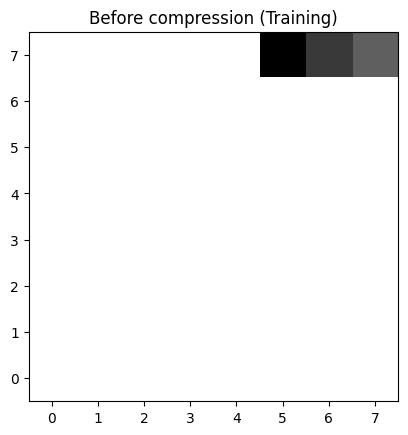

After compression (Training)
Shape: (1, 8, 8)


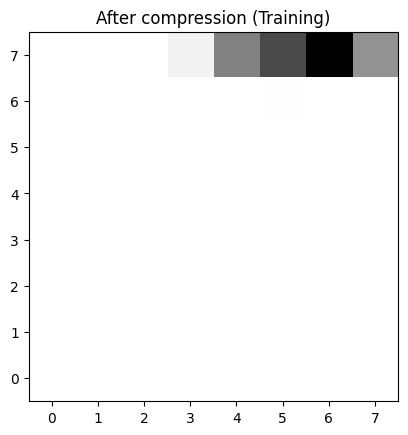

Epoch 92/200: 100%|██████████| 199/199 [00:00<00:00, 371.90it/s, Loss (BCE + VQ)=0.0355]


Epoch [92/200] summary:Average Loss: VQ + BCE = 0.0409,  Average loss: BCE = 0.0371 MSE = 0.003046302532019028 avg_perplexity = 58.81632270046215
Average validation set BCE loss: 0.04158118739724159


Epoch 93/200: 100%|██████████| 199/199 [00:00<00:00, 366.27it/s, Loss (BCE + VQ)=0.0723]


Epoch [93/200] summary:Average Loss: VQ + BCE = 0.0411,  Average loss: BCE = 0.0372 MSE = 0.0030909859254750326 avg_perplexity = 58.78006740550899
Average validation set BCE loss: 0.04140468761324882


Epoch 94/200: 100%|██████████| 199/199 [00:00<00:00, 367.45it/s, Loss (BCE + VQ)=0.0404]


...

Epoch [104/200] summary:Average Loss: VQ + BCE = 0.0405,  Average loss: BCE = 0.0367 MSE = 0.0029749074271042367 avg_perplexity = 59.64103413107407
Average validation set BCE loss: 0.041387570649385454


Epoch 105/200: 100%|██████████| 199/199 [00:00<00:00, 362.42it/s, Loss (BCE + VQ)=0.0454]


Epoch [105/200] summary:Average Loss: VQ + BCE = 0.0405,  Average loss: BCE = 0.0367 MSE = 0.002964393826594679 avg_perplexity = 59.32079042022552
Average validation set BCE loss: 0.04099151864647865


Epoch 106/200: 100%|██████████| 199/199 [00:00<00:00, 363.32it/s, Loss (BCE + VQ)=0.077] 


Epoch [106/200] summary:Average Loss: VQ + BCE = 0.0407,  Average loss: BCE = 0.0367 MSE = 0.0029750904647502393 avg_perplexity = 59.62881527234561
Average validation set BCE loss: 0.04129344001412392
Before compression (Training)
Shape: (13, 8, 8)


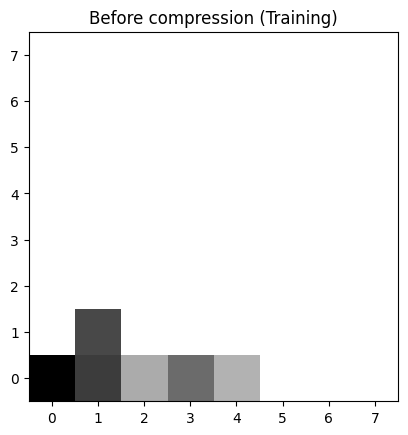

After compression (Training)
Shape: (1, 8, 8)


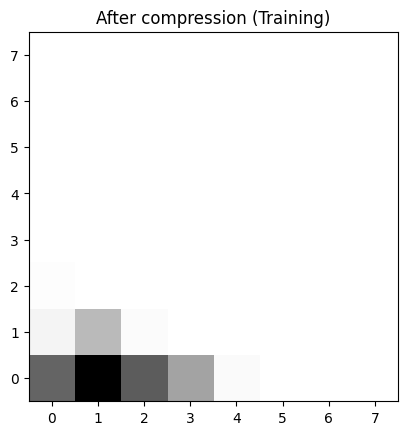

Epoch 107/200: 100%|██████████| 199/199 [00:00<00:00, 370.31it/s, Loss (BCE + VQ)=0.0368]


Epoch [107/200] summary:Average Loss: VQ + BCE = 0.0412,  Average loss: BCE = 0.0371 MSE = 0.0030651429045627167 avg_perplexity = 59.72571076819645
Average validation set BCE loss: 0.04125683605670929


Epoch 108/200: 100%|██████████| 199/199 [00:00<00:00, 372.87it/s, Loss (BCE + VQ)=0.0668]


Epoch [108/200] summary:Average Loss: VQ + BCE = 0.0405,  Average loss: BCE = 0.0367 MSE = 0.0029685713605833563 avg_perplexity = 60.381804739410555
Average validation set BCE loss: 0.04100437089800835


Epoch 109/200: 100%|██████████| 199/199 [00:00<00:00, 370.38it/s, Loss (BCE + VQ)=0.0285]


...

Epoch [119/200] summary:Average Loss: VQ + BCE = 0.0401,  Average loss: BCE = 0.0363 MSE = 0.0029031357461184112 avg_perplexity = 61.30393049345544
Average validation set BCE loss: 0.04112538173794746


Epoch 120/200: 100%|██████████| 199/199 [00:00<00:00, 358.46it/s, Loss (BCE + VQ)=0.0381]


Epoch [120/200] summary:Average Loss: VQ + BCE = 0.0401,  Average loss: BCE = 0.0363 MSE = 0.0028964972875815767 avg_perplexity = 61.63439202428463
Average validation set BCE loss: 0.0412457749247551


Epoch 121/200: 100%|██████████| 199/199 [00:00<00:00, 367.86it/s, Loss (BCE + VQ)=0.0458]


Epoch [121/200] summary:Average Loss: VQ + BCE = 0.0399,  Average loss: BCE = 0.0362 MSE = 0.002876630558950555 avg_perplexity = 61.6882547924866
Average validation set BCE loss: 0.040768231451511386
Before compression (Training)
Shape: (13, 8, 8)


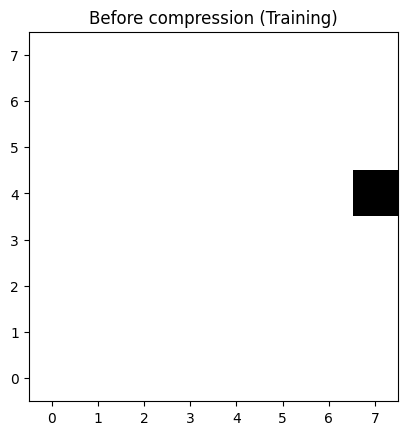

After compression (Training)
Shape: (1, 8, 8)


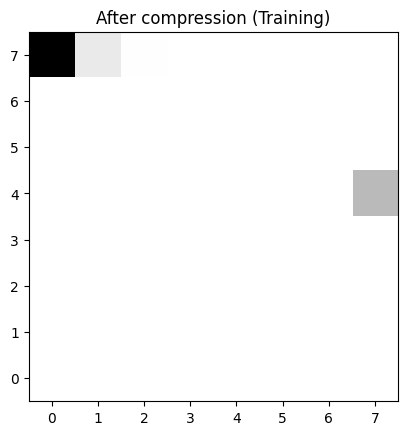

Epoch 122/200: 100%|██████████| 199/199 [00:00<00:00, 366.62it/s, Loss (BCE + VQ)=0.0447]


Epoch [122/200] summary:Average Loss: VQ + BCE = 0.0400,  Average loss: BCE = 0.0363 MSE = 0.0028804544477615897 avg_perplexity = 61.85718001552563
Average validation set BCE loss: 0.04143399596214294


Epoch 123/200: 100%|██████████| 199/199 [00:00<00:00, 362.57it/s, Loss (BCE + VQ)=0.0666]


Epoch [123/200] summary:Average Loss: VQ + BCE = 0.0397,  Average loss: BCE = 0.0361 MSE = 0.0028354749475470067 avg_perplexity = 61.539190388205064
Average validation set BCE loss: 0.04123539850115776


Epoch 124/200: 100%|██████████| 199/199 [00:00<00:00, 365.11it/s, Loss (BCE + VQ)=0.0503]


...

Epoch [134/200] summary:Average Loss: VQ + BCE = 0.0396,  Average loss: BCE = 0.0359 MSE = 0.002801264742688842 avg_perplexity = 61.97796487089378
Average validation set BCE loss: 0.04108775742352009


Epoch 135/200: 100%|██████████| 199/199 [00:00<00:00, 353.22it/s, Loss (BCE + VQ)=0.046] 


Epoch [135/200] summary:Average Loss: VQ + BCE = 0.0397,  Average loss: BCE = 0.0360 MSE = 0.0028299676487222314 avg_perplexity = 61.79199465075929
Average validation set BCE loss: 0.04100634902715683


Epoch 136/200: 100%|██████████| 199/199 [00:00<00:00, 352.85it/s, Loss (BCE + VQ)=0.0432]


Epoch [136/200] summary:Average Loss: VQ + BCE = 0.0396,  Average loss: BCE = 0.0359 MSE = 0.002813091550148724 avg_perplexity = 62.21902596171777
Average validation set BCE loss: 0.04050624258816242
Before compression (Training)
Shape: (13, 8, 8)


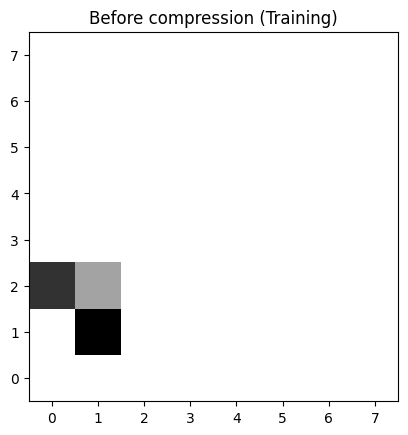

After compression (Training)
Shape: (1, 8, 8)


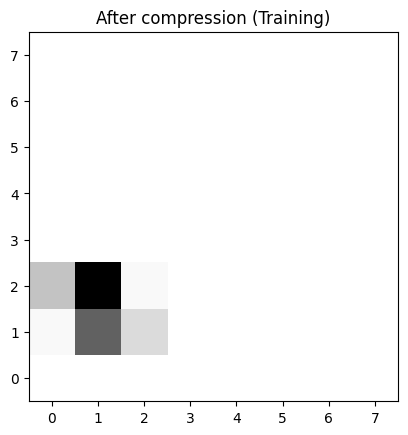

Epoch 137/200: 100%|██████████| 199/199 [00:00<00:00, 364.70it/s, Loss (BCE + VQ)=0.0361]


Epoch [137/200] summary:Average Loss: VQ + BCE = 0.0395,  Average loss: BCE = 0.0358 MSE = 0.002789044538606426 avg_perplexity = 62.191996195807526
Average validation set BCE loss: 0.04159847497940063


Epoch 138/200: 100%|██████████| 199/199 [00:00<00:00, 364.24it/s, Loss (BCE + VQ)=0.0503]


Epoch [138/200] summary:Average Loss: VQ + BCE = 0.0395,  Average loss: BCE = 0.0358 MSE = 0.0027861505075259573 avg_perplexity = 62.23605724315547
Average validation set BCE loss: 0.040917396545410156


Epoch 139/200: 100%|██████████| 199/199 [00:00<00:00, 365.25it/s, Loss (BCE + VQ)=0.0387]


...

Epoch [149/200] summary:Average Loss: VQ + BCE = 0.0393,  Average loss: BCE = 0.0357 MSE = 0.002762321775297087 avg_perplexity = 62.347150400056314
Average validation set BCE loss: 0.04100687950849533


Epoch 150/200: 100%|██████████| 199/199 [00:00<00:00, 376.56it/s, Loss (BCE + VQ)=0.0479]


Epoch [150/200] summary:Average Loss: VQ + BCE = 0.0392,  Average loss: BCE = 0.0356 MSE = 0.0027278674153339622 avg_perplexity = 62.41107394347838
Average validation set BCE loss: 0.04100069478154182


Epoch 151/200: 100%|██████████| 199/199 [00:00<00:00, 377.02it/s, Loss (BCE + VQ)=0.0698]


Epoch [151/200] summary:Average Loss: VQ + BCE = 0.0395,  Average loss: BCE = 0.0358 MSE = 0.002777410363404071 avg_perplexity = 62.39575605536226
Average validation set BCE loss: 0.04135665036737919
Before compression (Training)
Shape: (13, 8, 8)


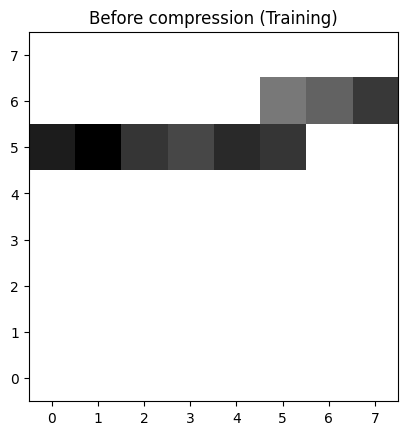

After compression (Training)
Shape: (1, 8, 8)


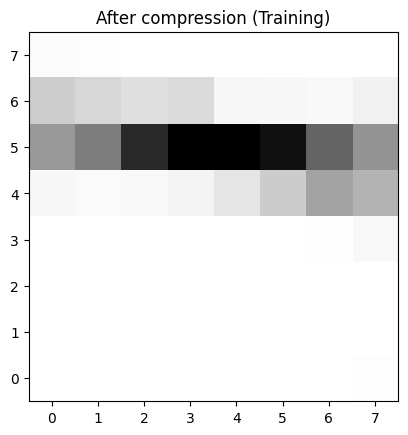

Epoch 152/200: 100%|██████████| 199/199 [00:00<00:00, 352.04it/s, Loss (BCE + VQ)=0.0342]


Epoch [152/200] summary:Average Loss: VQ + BCE = 0.0392,  Average loss: BCE = 0.0356 MSE = 0.0027388077792032954 avg_perplexity = 62.560673967677744
Average validation set BCE loss: 0.04125840663909912


Epoch 153/200: 100%|██████████| 199/199 [00:00<00:00, 361.94it/s, Loss (BCE + VQ)=0.045] 


Epoch [153/200] summary:Average Loss: VQ + BCE = 0.0392,  Average loss: BCE = 0.0356 MSE = 0.0027352448379686428 avg_perplexity = 62.640133220346726
Average validation set BCE loss: 0.04162189662456513


Epoch 154/200: 100%|██████████| 199/199 [00:00<00:00, 365.80it/s, Loss (BCE + VQ)=0.045] 


...

Epoch [164/200] summary:Average Loss: VQ + BCE = 0.0389,  Average loss: BCE = 0.0354 MSE = 0.002690626642942878 avg_perplexity = 63.19169083791761
Average validation set BCE loss: 0.04070639461278915


Epoch 165/200: 100%|██████████| 199/199 [00:00<00:00, 358.82it/s, Loss (BCE + VQ)=0.0361]


Epoch [165/200] summary:Average Loss: VQ + BCE = 0.0387,  Average loss: BCE = 0.0352 MSE = 0.002648309455253184 avg_perplexity = 62.877414482921814
Average validation set BCE loss: 0.04166032895445824


Epoch 166/200: 100%|██████████| 199/199 [00:00<00:00, 357.36it/s, Loss (BCE + VQ)=0.0699]


Epoch [166/200] summary:Average Loss: VQ + BCE = 0.0388,  Average loss: BCE = 0.0353 MSE = 0.0026560782890149097 avg_perplexity = 63.34355403190881
Average validation set BCE loss: 0.041419374942779544
Before compression (Training)
Shape: (13, 8, 8)


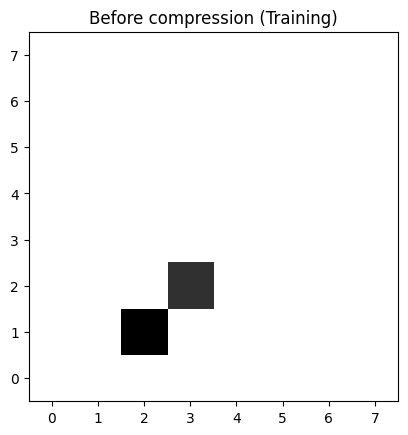

After compression (Training)
Shape: (1, 8, 8)


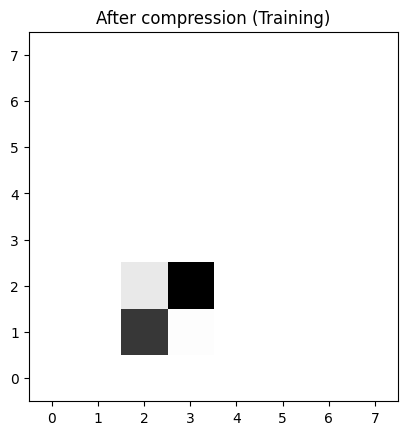

Epoch 167/200: 100%|██████████| 199/199 [00:00<00:00, 362.57it/s, Loss (BCE + VQ)=0.0585]


Epoch [167/200] summary:Average Loss: VQ + BCE = 0.0390,  Average loss: BCE = 0.0354 MSE = 0.0027110526594450353 avg_perplexity = 63.25096422703422
Average validation set BCE loss: 0.04092444591224194


Epoch 168/200: 100%|██████████| 199/199 [00:00<00:00, 360.42it/s, Loss (BCE + VQ)=0.0517]


Epoch [168/200] summary:Average Loss: VQ + BCE = 0.0388,  Average loss: BCE = 0.0353 MSE = 0.0026762412349698155 avg_perplexity = 62.80337386394865
Average validation set BCE loss: 0.04103442765772343


Epoch 169/200: 100%|██████████| 199/199 [00:00<00:00, 363.34it/s, Loss (BCE + VQ)=0.0541]


...

Epoch [179/200] summary:Average Loss: VQ + BCE = 0.0382,  Average loss: BCE = 0.0348 MSE = 0.0025751900182915243 avg_perplexity = 63.49783367367845
Average validation set BCE loss: 0.04111152440309525


Epoch 180/200: 100%|██████████| 199/199 [00:00<00:00, 359.31it/s, Loss (BCE + VQ)=0.0413]


Epoch [180/200] summary:Average Loss: VQ + BCE = 0.0384,  Average loss: BCE = 0.0349 MSE = 0.002589715409546566 avg_perplexity = 63.01723414090411
Average validation set BCE loss: 0.041151600703597066


Epoch 181/200: 100%|██████████| 199/199 [00:00<00:00, 367.25it/s, Loss (BCE + VQ)=0.0262]


Epoch [181/200] summary:Average Loss: VQ + BCE = 0.0383,  Average loss: BCE = 0.0348 MSE = 0.0025701801440018656 avg_perplexity = 63.520613713480124
Average validation set BCE loss: 0.041077567636966704
Before compression (Training)
Shape: (13, 8, 8)


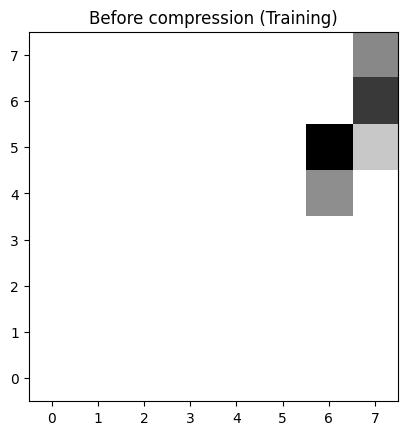

After compression (Training)
Shape: (1, 8, 8)


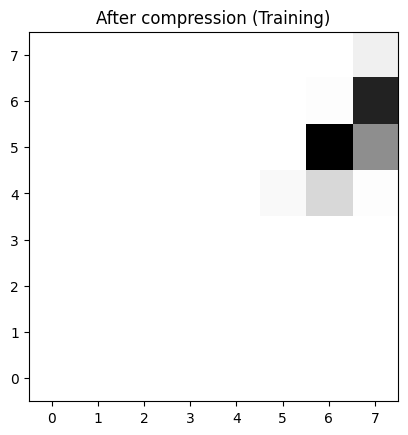

Epoch 182/200: 100%|██████████| 199/199 [00:00<00:00, 372.11it/s, Loss (BCE + VQ)=0.0388]


Epoch [182/200] summary:Average Loss: VQ + BCE = 0.0385,  Average loss: BCE = 0.0350 MSE = 0.0026141202291380147 avg_perplexity = 63.33099713157769
Average validation set BCE loss: 0.04175506755709648


Epoch 183/200: 100%|██████████| 199/199 [00:00<00:00, 371.05it/s, Loss (BCE + VQ)=0.0492]


Epoch [183/200] summary:Average Loss: VQ + BCE = 0.0384,  Average loss: BCE = 0.0349 MSE = 0.0026020460163041874 avg_perplexity = 63.576247881405315
Average validation set BCE loss: 0.04143003076314926


Epoch 184/200: 100%|██████████| 199/199 [00:00<00:00, 350.99it/s, Loss (BCE + VQ)=0.0268]


...

Epoch [194/200] summary:Average Loss: VQ + BCE = 0.0381,  Average loss: BCE = 0.0347 MSE = 0.002540072619835448 avg_perplexity = 63.791832487786834
Average validation set BCE loss: 0.041076965630054474


Epoch 195/200: 100%|██████████| 199/199 [00:00<00:00, 374.55it/s, Loss (BCE + VQ)=0.0388]


Epoch [195/200] summary:Average Loss: VQ + BCE = 0.0381,  Average loss: BCE = 0.0347 MSE = 0.0025342705193907022 avg_perplexity = 64.1221904371252
Average validation set BCE loss: 0.040102618560194966


Epoch 196/200: 100%|██████████| 199/199 [00:00<00:00, 373.63it/s, Loss (BCE + VQ)=0.0353]


Epoch [196/200] summary:Average Loss: VQ + BCE = 0.0382,  Average loss: BCE = 0.0348 MSE = 0.002566135686181074 avg_perplexity = 64.07057288663471
Average validation set BCE loss: 0.041330157220363616
Before compression (Training)
Shape: (13, 8, 8)


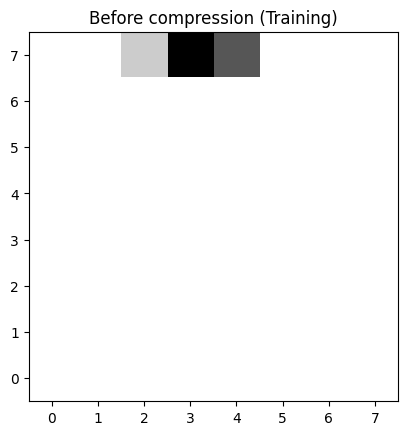

After compression (Training)
Shape: (1, 8, 8)


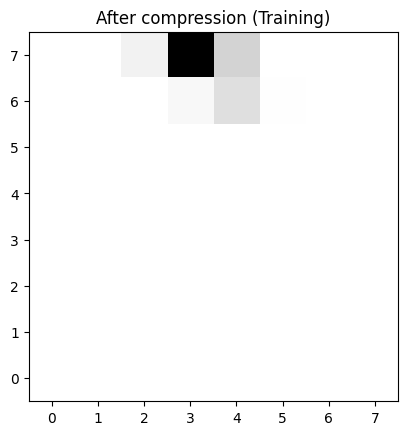

Epoch 197/200: 100%|██████████| 199/199 [00:00<00:00, 368.23it/s, Loss (BCE + VQ)=0.0354]


Epoch [197/200] summary:Average Loss: VQ + BCE = 0.0379,  Average loss: BCE = 0.0346 MSE = 0.0025046783997841066 avg_perplexity = 63.60417781043891
Average validation set BCE loss: 0.04112544804811478


Epoch 198/200: 100%|██████████| 199/199 [00:00<00:00, 373.96it/s, Loss (BCE + VQ)=0.0494]


Epoch [198/200] summary:Average Loss: VQ + BCE = 0.0381,  Average loss: BCE = 0.0347 MSE = 0.0025379763800304515 avg_perplexity = 63.78664440365892
Average validation set BCE loss: 0.04116079472005367


Epoch 199/200: 100%|██████████| 199/199 [00:00<00:00, 373.09it/s, Loss (BCE + VQ)=0.0258]


Epoch [199/200] summary:Average Loss: VQ + BCE = 0.0381,  Average loss: BCE = 0.0346 MSE = 0.0025237799585848372 avg_perplexity = 64.0409327751428
Average validation set BCE loss: 0.041430216282606125


Epoch 200/200: 100%|██████████| 199/199 [00:00<00:00, 354.84it/s, Loss (BCE + VQ)=0.0464]


Epoch [200/200] summary:Average Loss: VQ + BCE = 0.0379,  Average loss: BCE = 0.0346 MSE = 0.002503377689053328 avg_perplexity = 64.14472782192517
Average validation set BCE loss: 0.04099166840314865
Before compression (Validation)
Shape: (64, 8, 8)


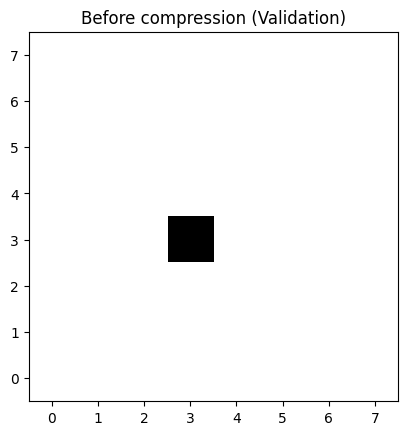

After compression (Validation)
Shape: (1, 8, 8)


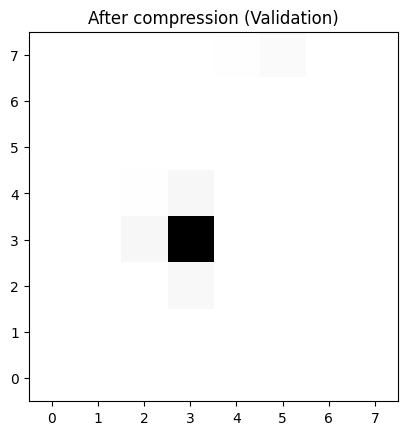

----------------------------------------
Patch = 0 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 2
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


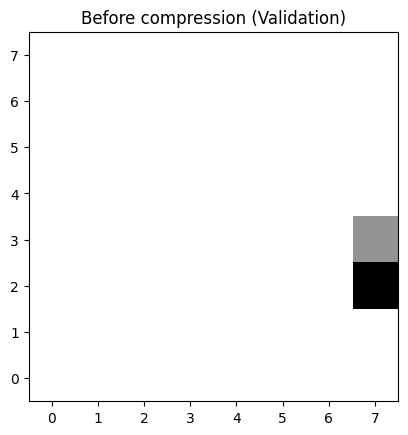

After compression (Validation)
Shape: (1, 8, 8)


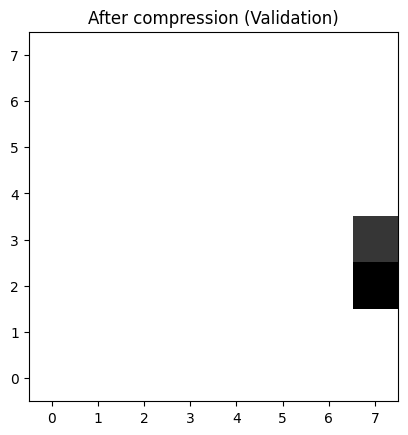

----------------------------------------
Patch = 1 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 2
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


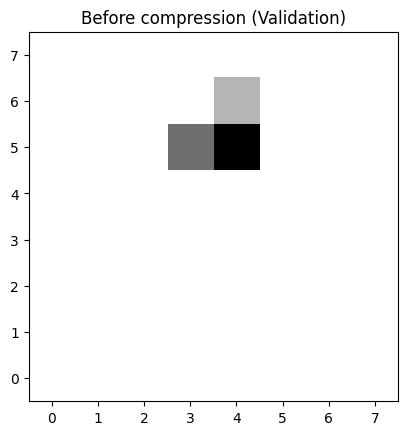

After compression (Validation)
Shape: (1, 8, 8)


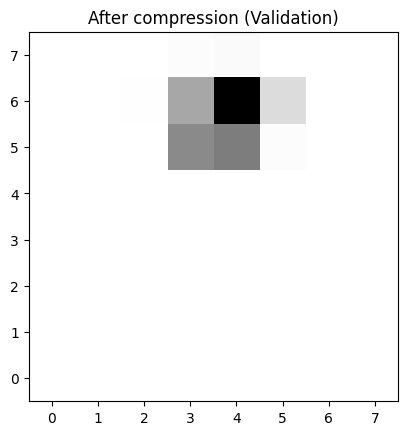

----------------------------------------
Patch = 2 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 2
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


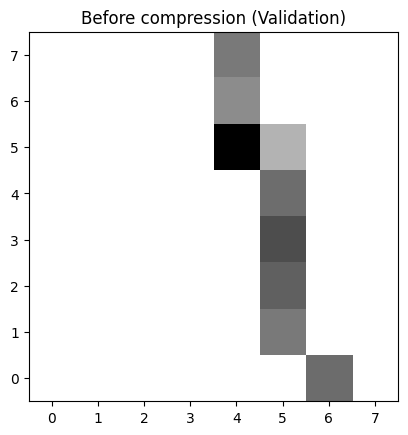

After compression (Validation)
Shape: (1, 8, 8)


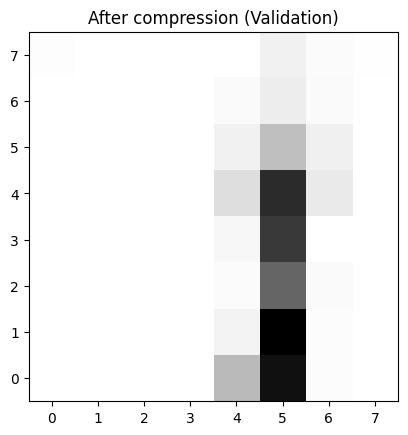

----------------------------------------
Patch = 3 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 2
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (61, 8, 8)


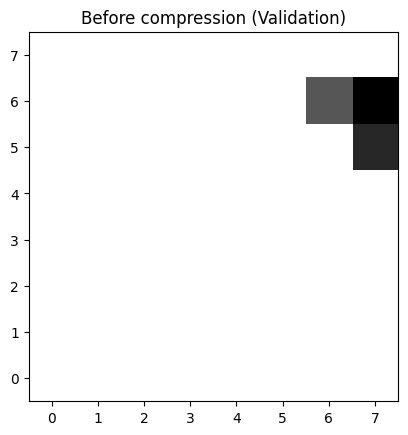

After compression (Validation)
Shape: (1, 8, 8)


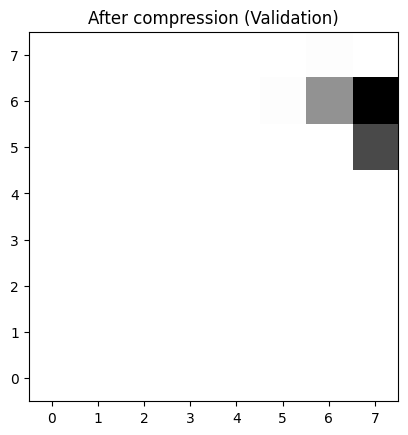

----------------------------------------
Patch = 4 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 2
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Saving trained model VQ-VAE


In [21]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs,
           d
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val, d)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val, d)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = model_tool._tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = model_tool._tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                cms_plots.plot_patch(
                    recon_patch_np_val[0], 
                    "After compression (Validation)"
                )
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                batch, indexes_enc, channel = z_q_val.shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------width_val------------------------")
                print(
                    f"Patch encoder output encoded into:"
                    f"codebook indexes = {indexes_enc}"
                )
                
            
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(d, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        d,
                        num_embeddings
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

<h3>VQ-VAE results analysis</h3>

In [22]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


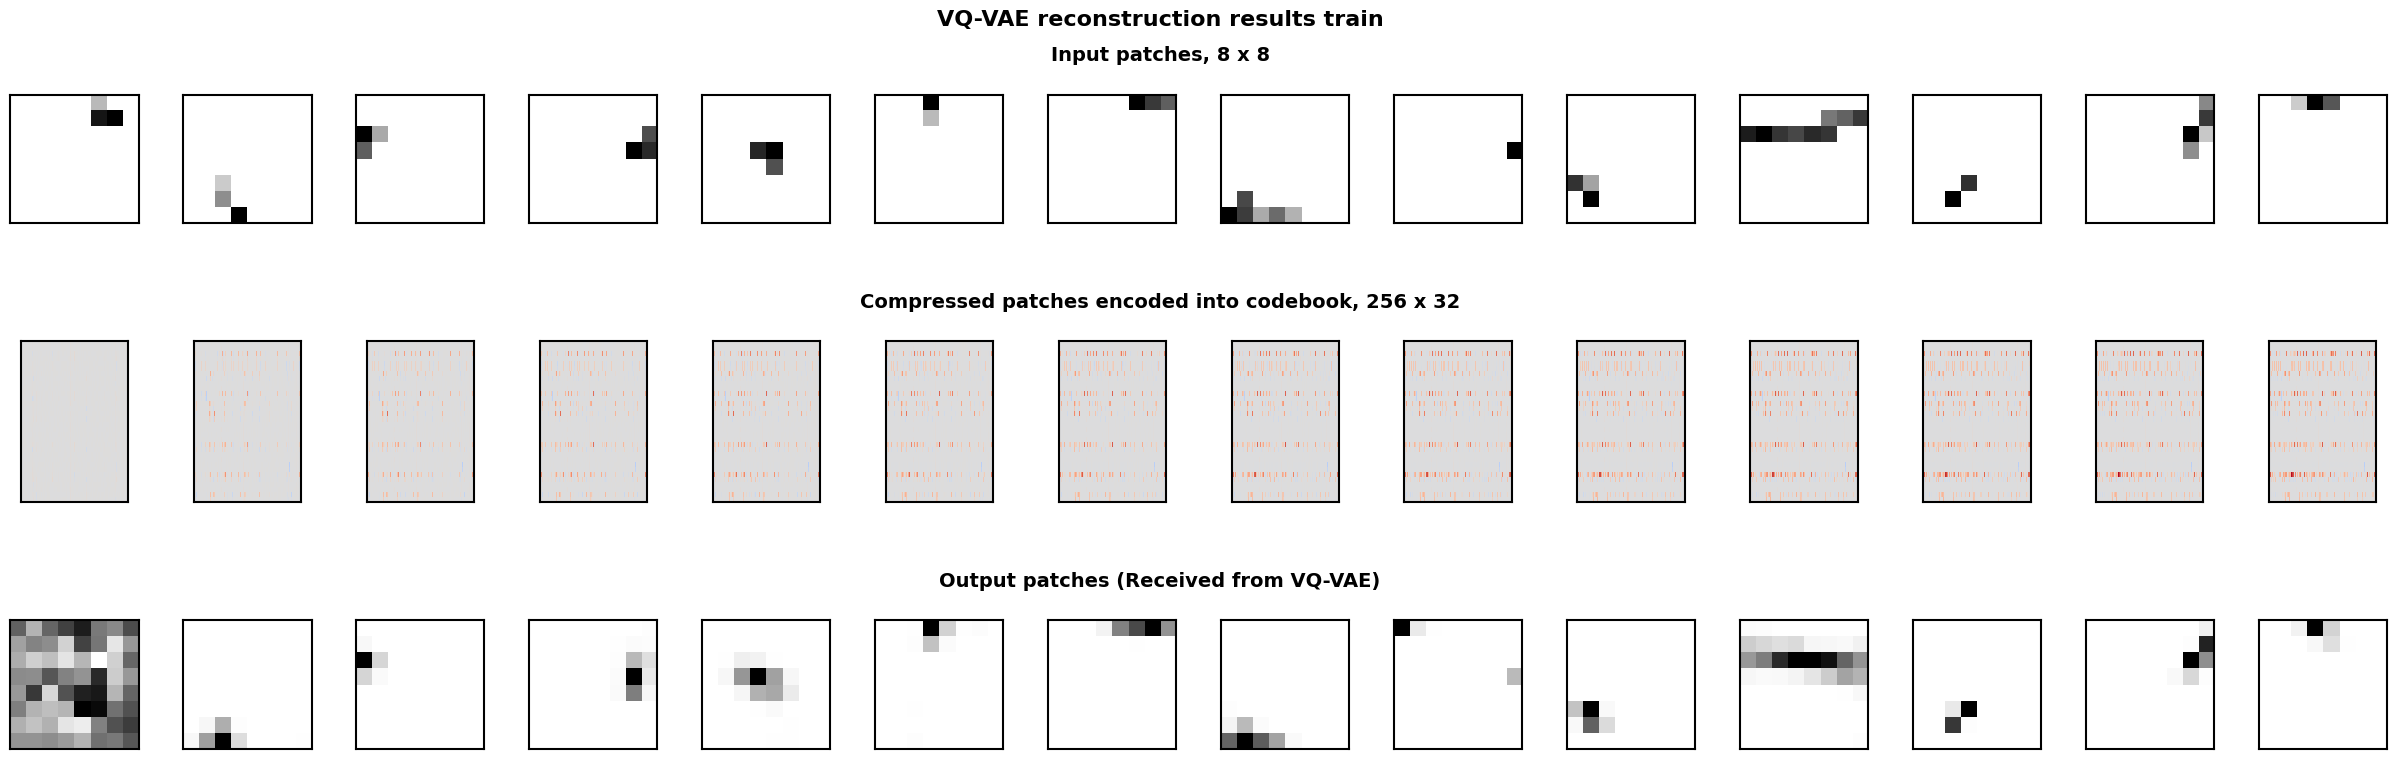

In [23]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

# NOTE: Some patches are blurry due to early collection in the epochs

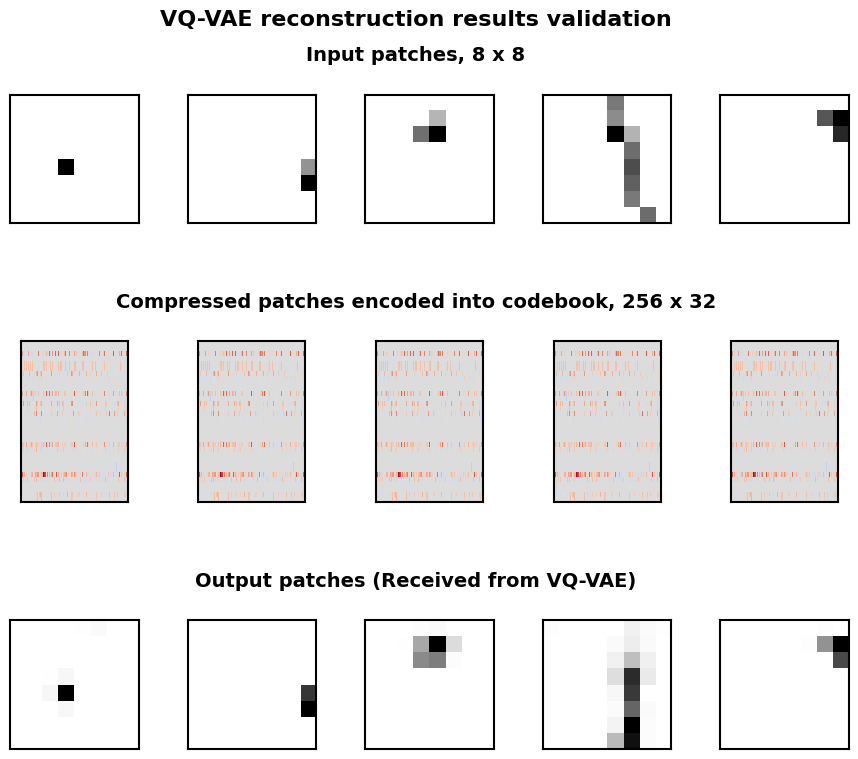

In [24]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results validation"
)

In [25]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.0253777913749218
encoder.1.weight 0.0037458587903529406
encoder.1.bias 0.0069175707176327705
encoder.3.weight 0.027721816673874855
encoder.4.weight 0.0032322665210813284
encoder.4.bias 0.0031201071105897427
encoder.6.weight 0.03533702716231346
encoder.7.weight 0.0015384857542812824
encoder.7.bias 0.0032409559935331345
encoder.8.stack.0.res_block.1.weight 0.013996260240674019
encoder.8.stack.0.res_block.3.weight 0.013219027779996395
encoder.8.stack.1.res_block.1.weight 0.012276283465325832
encoder.8.stack.1.res_block.3.weight 0.013475858606398106
fc_encoder_input.layers.0.weight 0.018590489402413368
fc_encoder_input.layers.0.bias 0.000548382056877017
fc_encoder_input.layers.1.weight 0.008844135329127312
fc_encoder_input.layers.1.bias 0.01442412193864584
vq_layer.embedding.weight 0.0011776043102145195
fc_decoder_input.layers.0.weight 0.019793855026364326
fc_decoder_input.layers.0.bias 0.046520788222551346
fc_decoder_input.layers.1.weight 0.00484

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


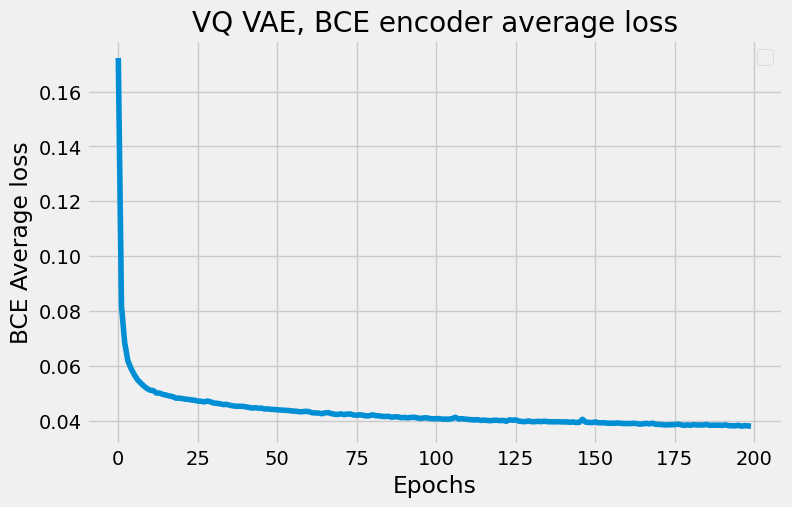

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [26]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [27]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("../bin/vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test, d)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 45), average BCE loss = 0.43677
Based on test set (size = 45), average codebook perplexity = 62.57747/256
Saved VQ-VAE test results


In [28]:
len(patches_before_test)

6

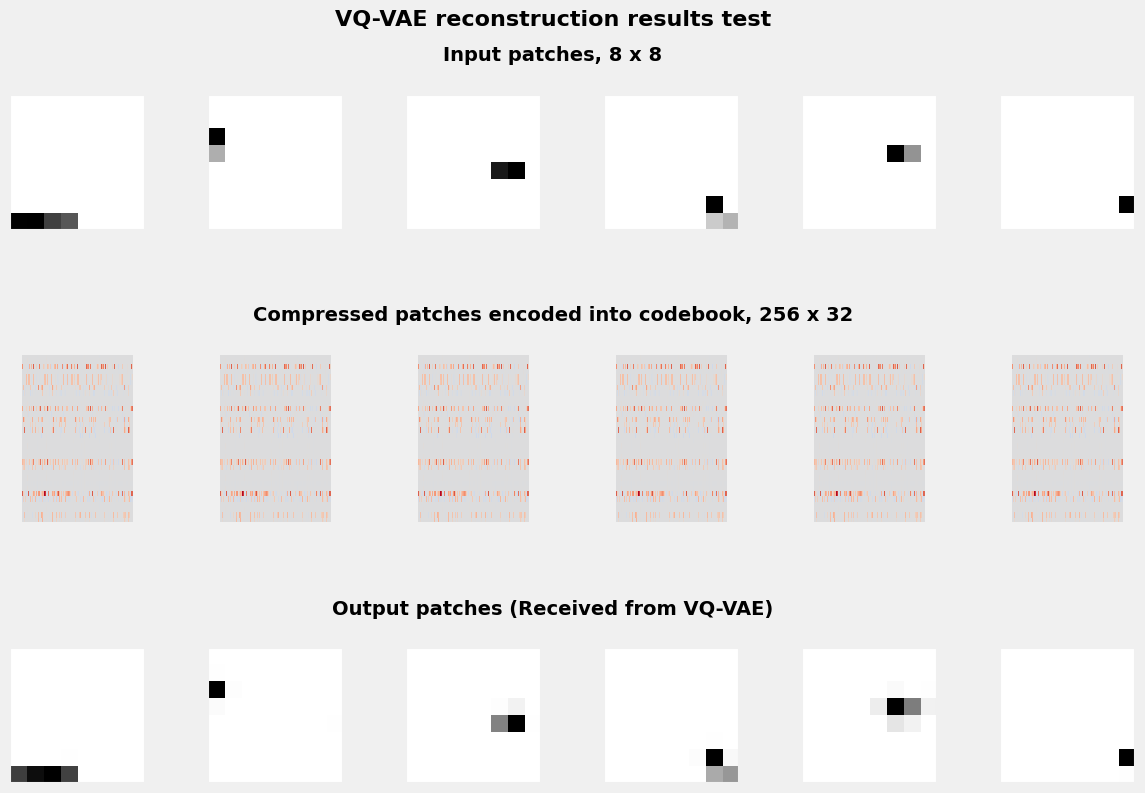

In [29]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")

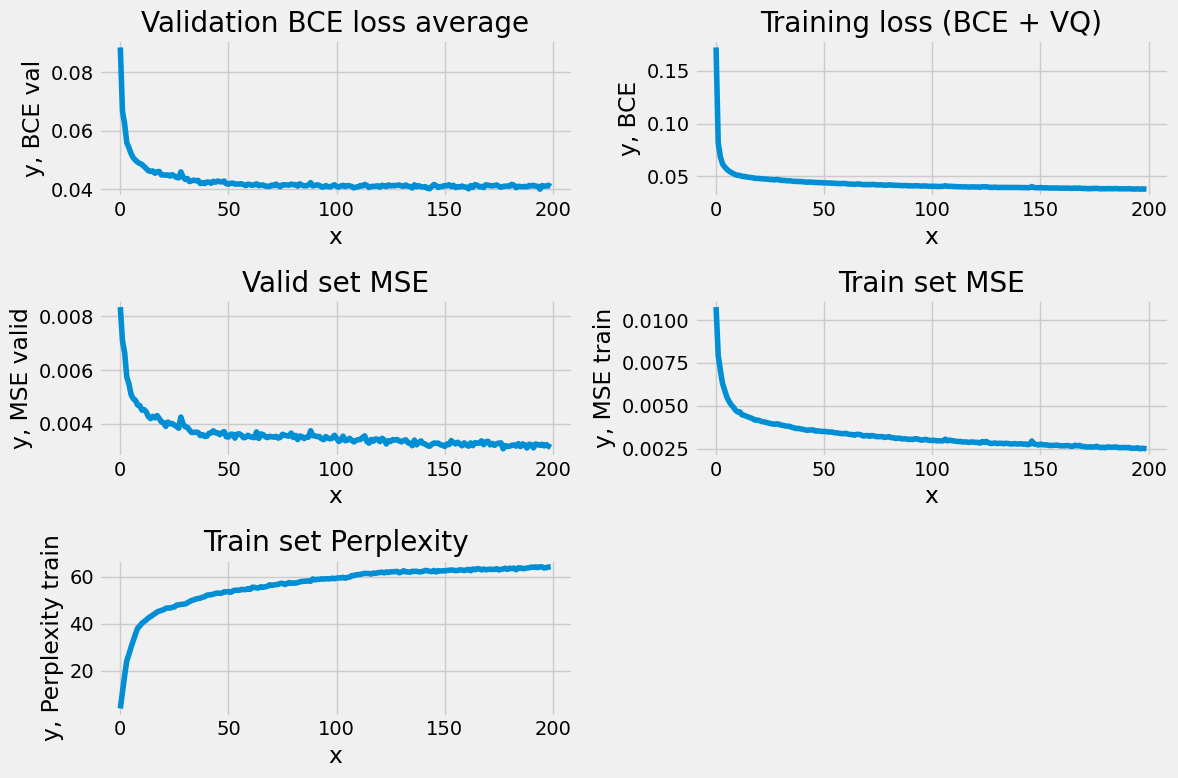

In [30]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)


In [31]:
patches_before_train

[array([[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.42745098, 0.46666667, 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.12941177, 0.        , 0.        ]], dtype=float32),
 array([[0.        , 0.        , 0.        , 0.88235295, 0.    